In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/train.csv')
df.columns = df.columns.str.strip()
print(df.shape)

(1460, 81)


In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65,8450,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80,9600,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68,11250,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60,9550,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84,14260,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000


In [4]:
df.describe()

,Id,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,10516.828082,6.099315,5.575342,1971.267808,1984.865753,443.639726,46.549315,567.240411,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,9981.264932,1.382997,1.112799,30.202904,20.645407,456.098091,161.319273,441.866955,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,223.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,383.500000,0.000000,477.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,712.250000,0.000000,808.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,5644.000000,1474.000000,2336.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
pd.set_option('display.max_rows', None)

missing = df.isna().sum()

missing[missing > 0]

Series([], dtype: int64)

In [6]:
threshold = 0.80 * len(df)
missing = df.isna().sum()
cols_to_drop = missing[missing > threshold]


((cols_to_drop / len(df)) * 100).round(2).sort_values(ascending=False)

Series([], dtype: float64)

In [7]:
df.columns = df.columns.str.strip()
df_clean = df.copy()

cols_to_drop = ['PoolQC', 'Fence', 'MiscFeature', 'Alley']
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

print(f"Colonnes restantes : {df_clean.shape[1]}")

Colonnes restantes : 77


In [8]:
df_clean['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

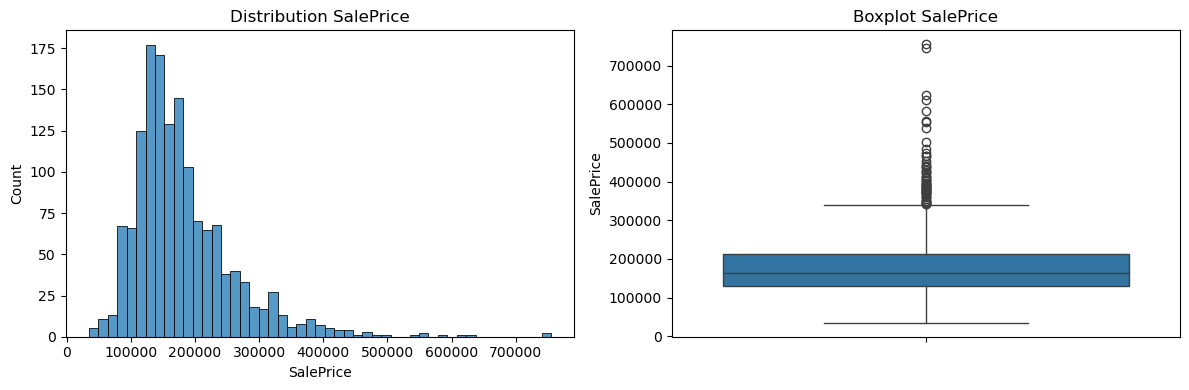

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_clean['SalePrice'], ax=axes[0])
axes[0].set_title('Distribution SalePrice')

sns.boxplot(y=df_clean['SalePrice'], ax=axes[1])
axes[1].set_title('Boxplot SalePrice')

plt.tight_layout()
plt.show()

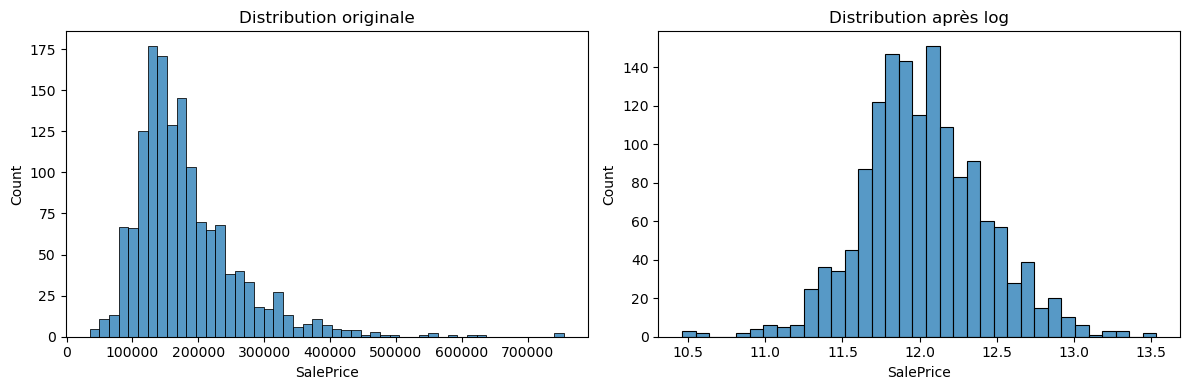

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_clean['SalePrice'], ax=axes[0])
axes[0].set_title('Distribution originale')

sns.histplot(np.log(df_clean['SalePrice']), ax=axes[1])
axes[1].set_title('Distribution après log')

plt.tight_layout()
plt.show()

In [13]:
df_clean['SalePrice'] = np.log(df_clean['SalePrice'])
df_clean.rename(columns={'SalePrice': 'SalePrice_log'}, inplace=True)

In [14]:
print(df_clean['SalePrice_log'].describe())

count    1460.000000
mean       12.024051
std         0.399452
min        10.460242
25%        11.775097
50%        12.001505
75%        12.273731
max        13.534473
Name: SalePrice_log, dtype: float64


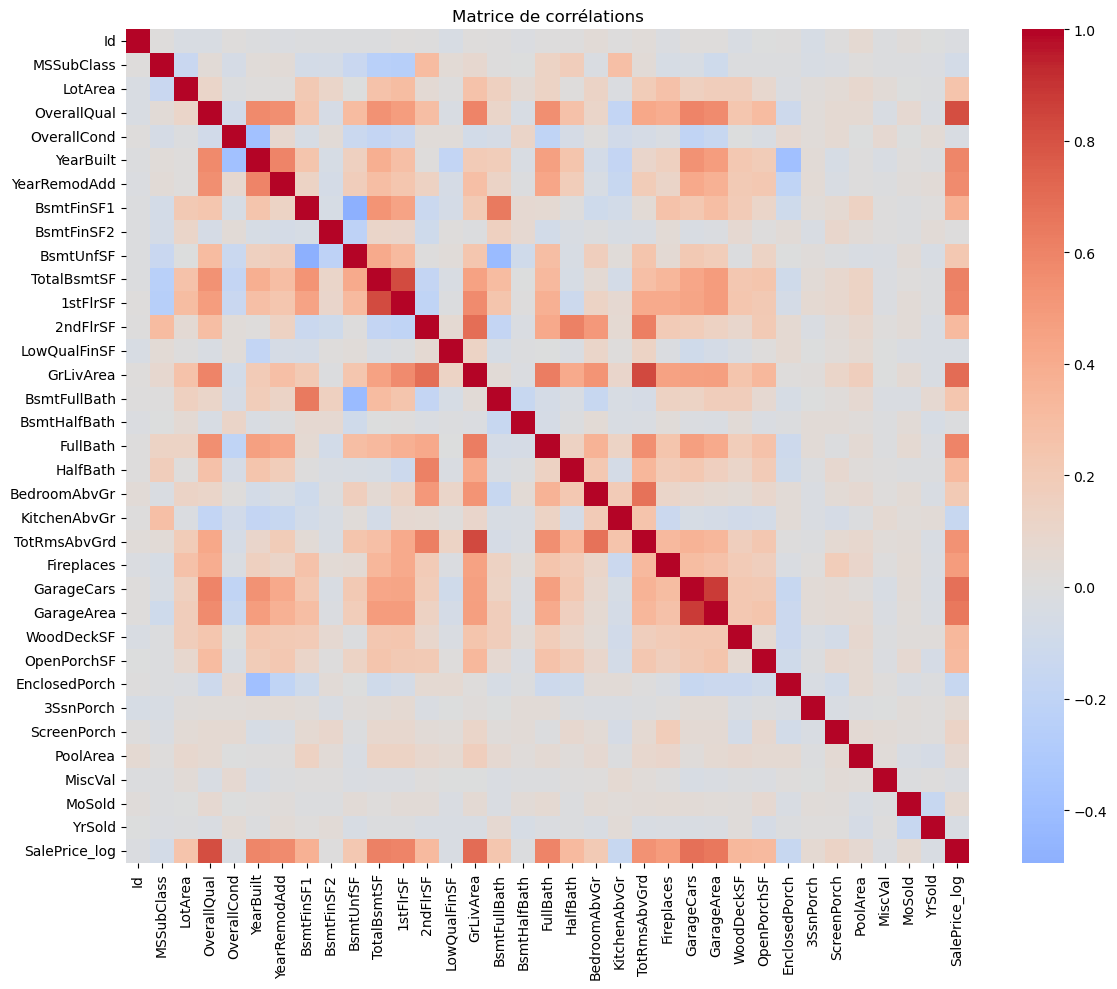

In [16]:
plt.figure(figsize=(12, 10))

correlations = df_clean.select_dtypes(include=['int64', 'float64']).corr()

sns.heatmap(correlations, 
            cmap='coolwarm',
            center=0,
            fmt='.1f')

plt.title('Matrice de corrélations')
plt.tight_layout()
plt.show()

In [17]:
print(df_clean[['GarageCars', 'GarageArea']].corr())

            GarageCars  GarageArea
GarageCars    1.000000    0.882475
GarageArea    0.882475    1.000000


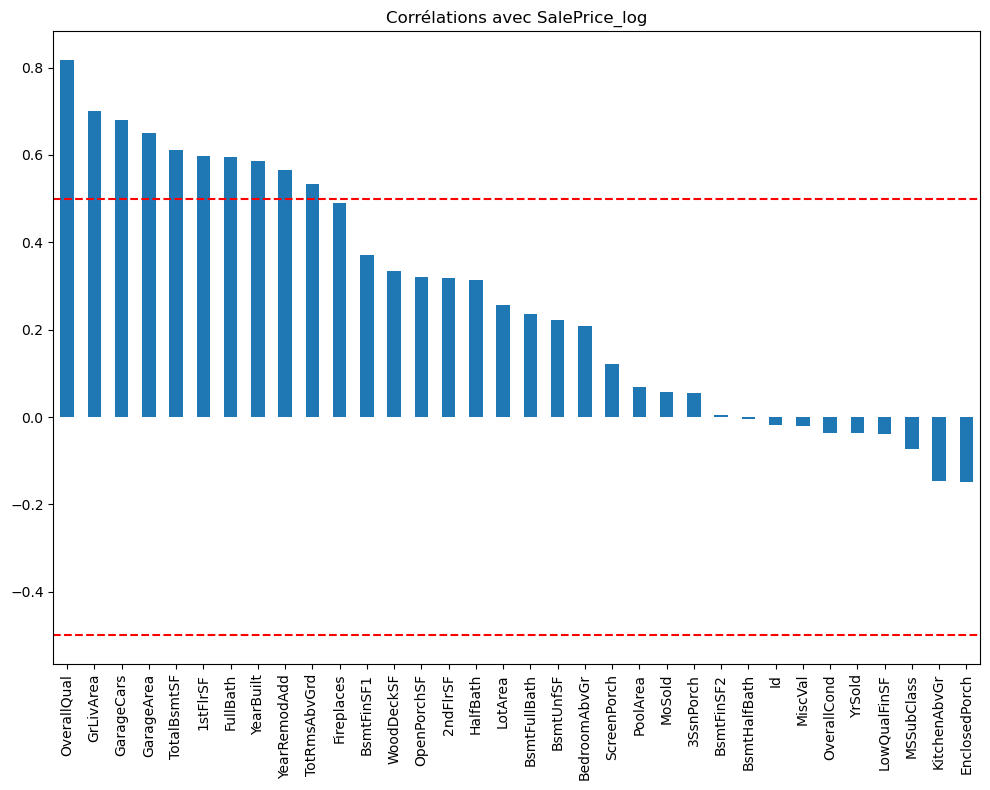

In [18]:
correlations_target = df_clean.select_dtypes(include=['int64', 'float64']).corr()['SalePrice_log'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlations_target.drop('SalePrice_log').plot(kind='bar')
plt.title('Corrélations avec SalePrice_log')
plt.axhline(y=0.5, color='r', linestyle='--', label='Seuil 0.5')
plt.axhline(y=-0.5, color='r', linestyle='--')
plt.tight_layout()
plt.show()